### The Monte Carlo Method

In [1]:
import math
import numpy as np
import matplotlib.pyplot as plt

In [2]:
def function(x):
    return math.log(x)/x

a = 1
b = 10
n = 10000
#np.random.seed(42)
count  = 0.0
in_area = 0.0
while count < n:

    x_coord = np.random.uniform(a,b)
    y_coord = np.random.uniform(0, 1/math.e)

    if y_coord < function(x_coord):
        in_area += 1
    count += 1

area_box = 9/np.e
area_under_curve = (in_area/count)*area_box
print(area_under_curve)

In [3]:
def sine(x):
    return math.sin(x)

In [4]:
a = 0
b = np.pi
n = 10000
#np.random.seed(42)
count  = 0.0
 
area = []
for i in range(n):
    in_area = 0.0
    
    while count < n:
    
        
        x_coord = np.random.uniform(a,b)
        y_coord = np.random.uniform(-1, 1)
    
        if y_coord + 1 <= math.sin(x_coord)+1:
            in_area += 1
        count += 1
    
    area_box = np.pi
    area_under_curve = (in_area/count)*area_box
    area.append(area_under_curve)
#print(area)    
#area_under_curve = (in_area/count)*area_box
#print(area_under_curve)

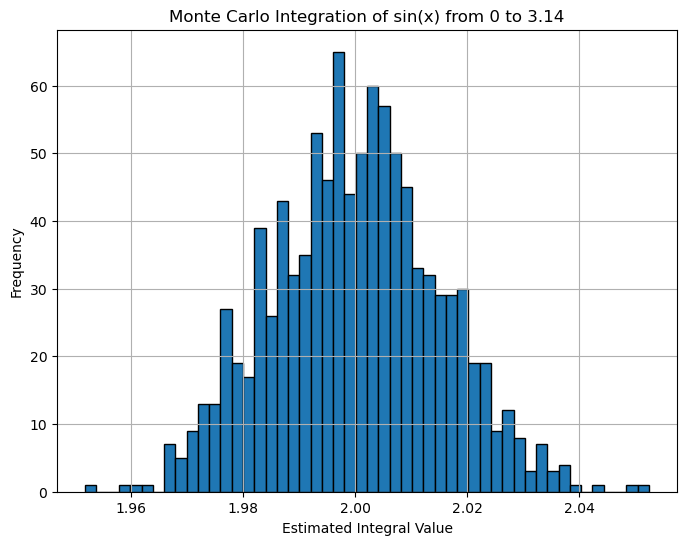

Mean estimated integral value: 2.000047
Standard deviation of estimates: 0.014870
True integral of sin(x) from 0 to pi: 2.0


In [5]:
import numpy as np
import matplotlib.pyplot as plt

# Define the function to integrate. Assuming 'function' was intended to be np.sin(x).
def function(x):
    return np.sin(x)

a = 0
b = np.pi
num_points_per_simulation = 10000 # 'n' from the original code
#np.random.seed(42)

num_simulations = 1000 # Number of times to repeat the simulation
estimated_areas = [] # List to store estimated area from each simulation

# Define the bounding box for Monte Carlo sampling
# For integral of sin(x) from 0 to pi, the y-values range from 0 to 1.
# We set the sampling box for y_coord from 0 to 1.
min_y_box_sampling = 0
max_y_box_sampling = 1

# Area of the bounding box: (width) * (height)
bounding_box_total_area = (b - a) * (max_y_box_sampling - min_y_box_sampling)

for _ in range(num_simulations): # Loop for 1000 simulations
    count_inside = 0.0 # Points falling under the curve (y_rand <= f(x_rand))
    total_points_generated = 0.0 # Total random points generated for this simulation

    while total_points_generated < num_points_per_simulation:
        x_coord = np.random.uniform(a, b) # Random x in [0, pi]
        y_coord = np.random.uniform(min_y_box_sampling, max_y_box_sampling) # Random y in [0, 1]

        # Check if the point is under the curve
        if y_coord <= function(x_coord):
            count_inside += 1
        total_points_generated += 1

    # Calculate the area estimate for this single simulation
    estimated_area = (count_inside / total_points_generated) * bounding_box_total_area
    estimated_areas.append(estimated_area)

# Now, plot the histogram of the estimated areas
plt.figure(figsize=(8, 6))
plt.hist(estimated_areas, bins=50, edgecolor='black')
plt.title(f'Monte Carlo Integration of sin(x) from {round(a, 2)} to {round(b, 2)}')
plt.xlabel('Estimated Integral Value')
plt.ylabel('Frequency')
plt.grid(True)
plt.show()

# Calculate and print the mean and standard deviation of the estimates
mean_result = np.mean(estimated_areas)
std_dev_result = np.std(estimated_areas)
print(f"Mean estimated integral value: {mean_result:.6f}")
print(f"Standard deviation of estimates: {std_dev_result:.6f}")
print(f"True integral of sin(x) from 0 to pi: {2.0}")
